In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import numpy as np
import sys
import glob

In [2]:
filename = f'17kV_Incision001_Ch2.csv'
filepath = os.path.join('Chiang_Incision', filename)

# Read CSV without header
df = pd.read_csv(filepath, header=None)
df[1] = df[1] - df[1].mean()
mask = (df[0] >= -0.5e-7) & (df[0] <= -6e-7)
# df = df[mask]

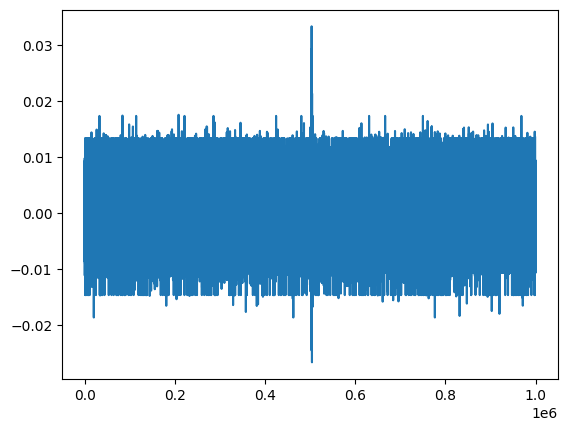

In [3]:
plt.plot(df[1])

In [12]:
df_squared = df[1].abs()
df_squared.mean()

np.float64(0.0032481904433101917)

In [ ]:
kde = stats.gaussian_kde(df[1])
x = np.linspace(df[1].min(), df[1].max(), 500)
plt.plot(x, kde(x), label='KDE')
plt.legend()
plt.show()


In [ ]:
plt.plot(df[mask][0], df[mask][1])
plt.show()

In [ ]:
# Spent so long to develop this method of detecting PD occurences
# Found a better one at the last min
# RIP to my effort and hard work

x = np.linspace(df[1].min(), df[1].max(), 500)
kde = stats.gaussian_kde(df[1])
y = kde(x)
max_kde = np.max(y)
indices = np.where(y >= (max_kde * 0.004))[0]   
idx = indices[-1]
print(f'Maximum KDE value: {max_kde:.6f}')
print(f'Indexes: {idx}')
print(f'Corresponding x values: {x[idx]}')

Found 47 files to plot.


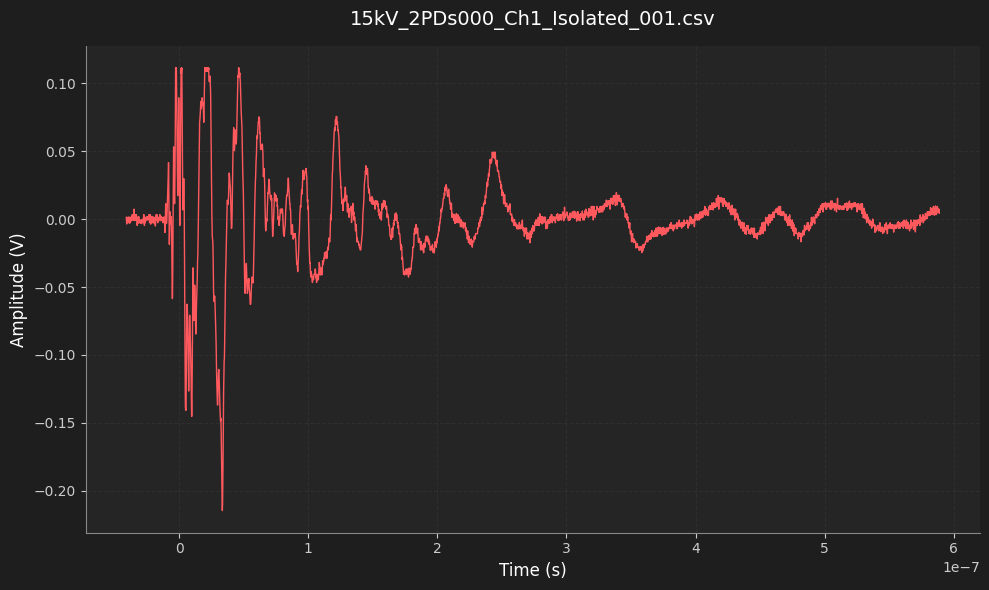

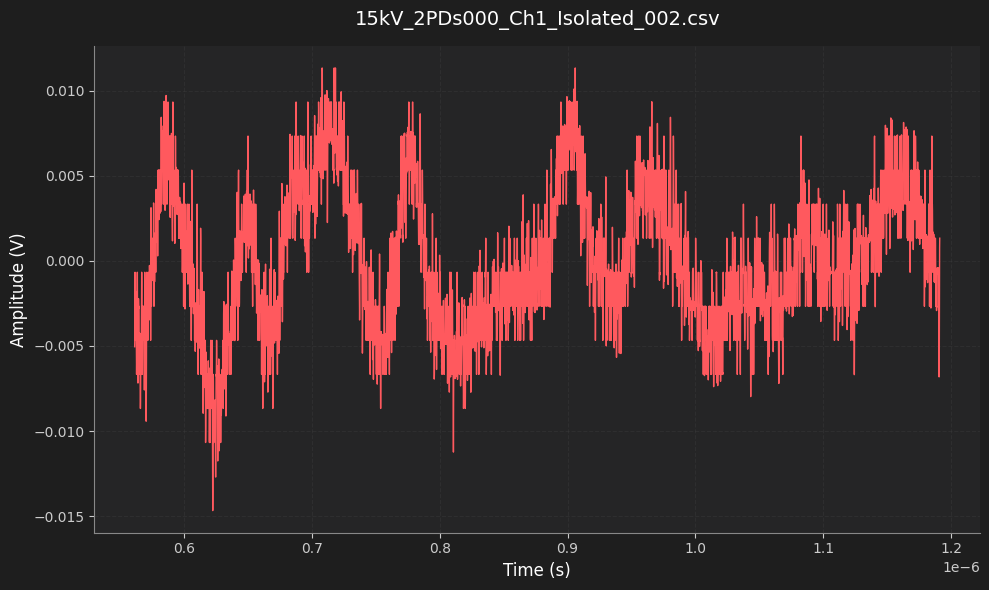

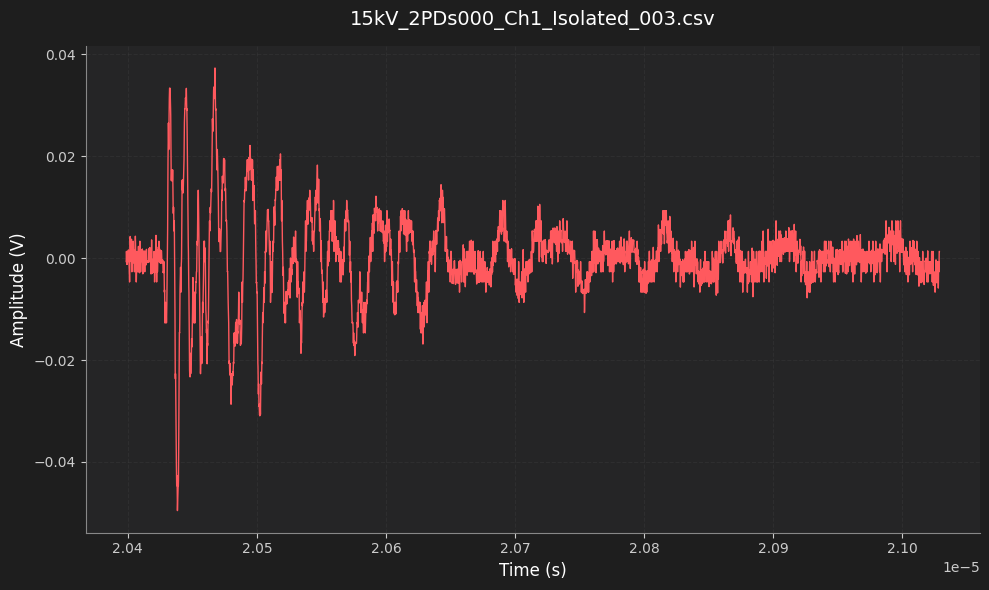

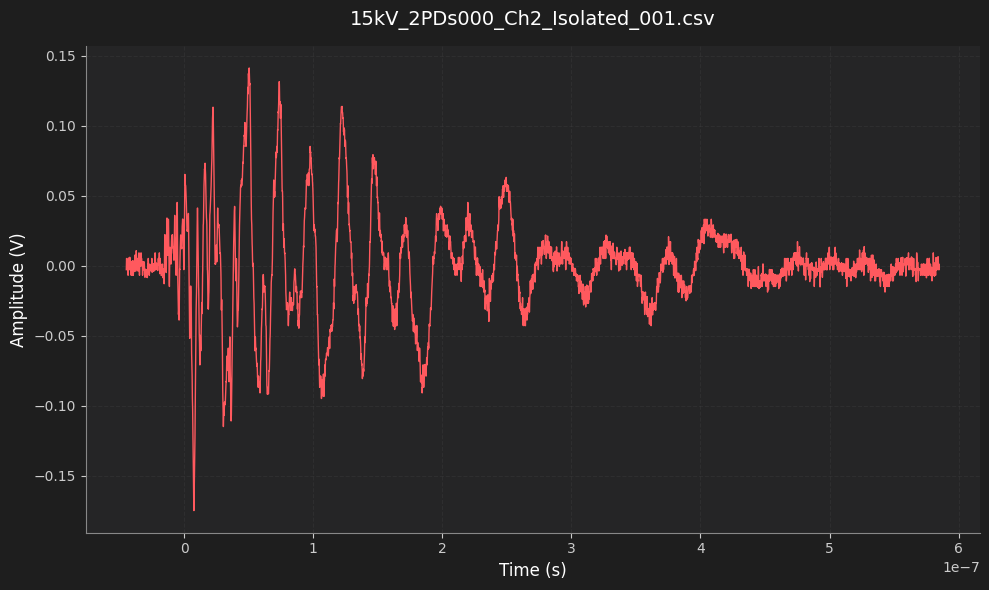

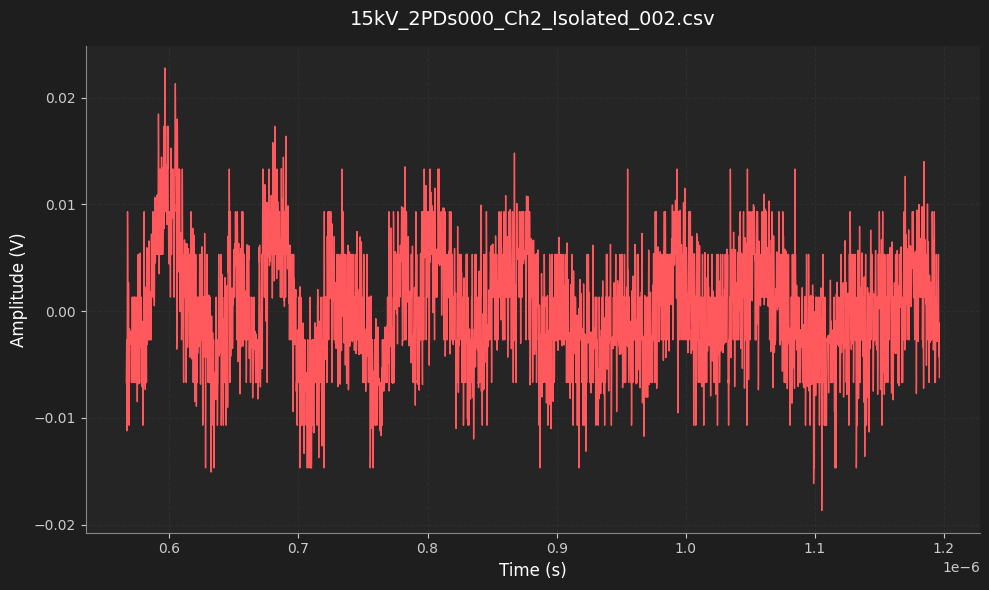

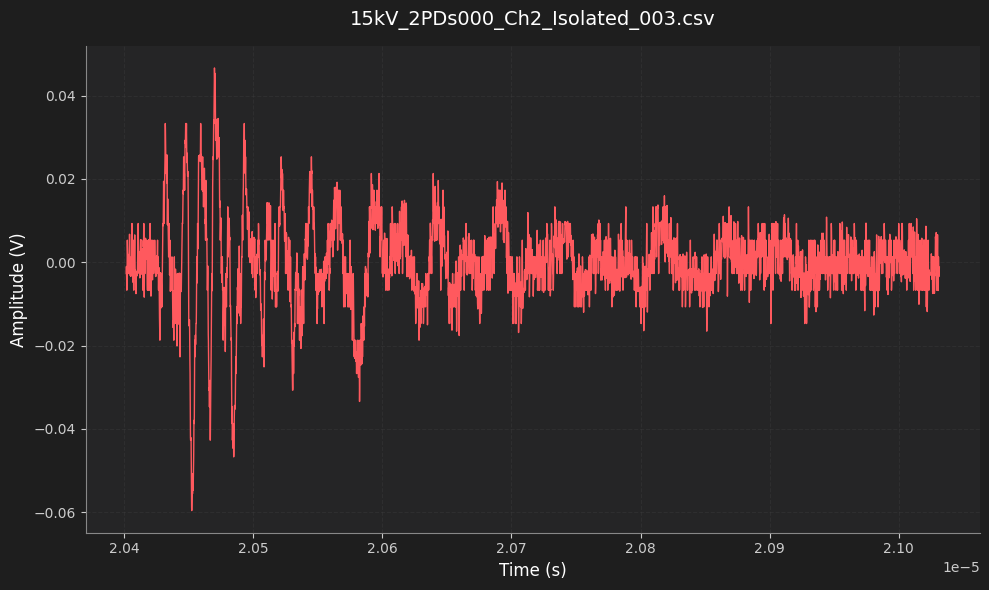

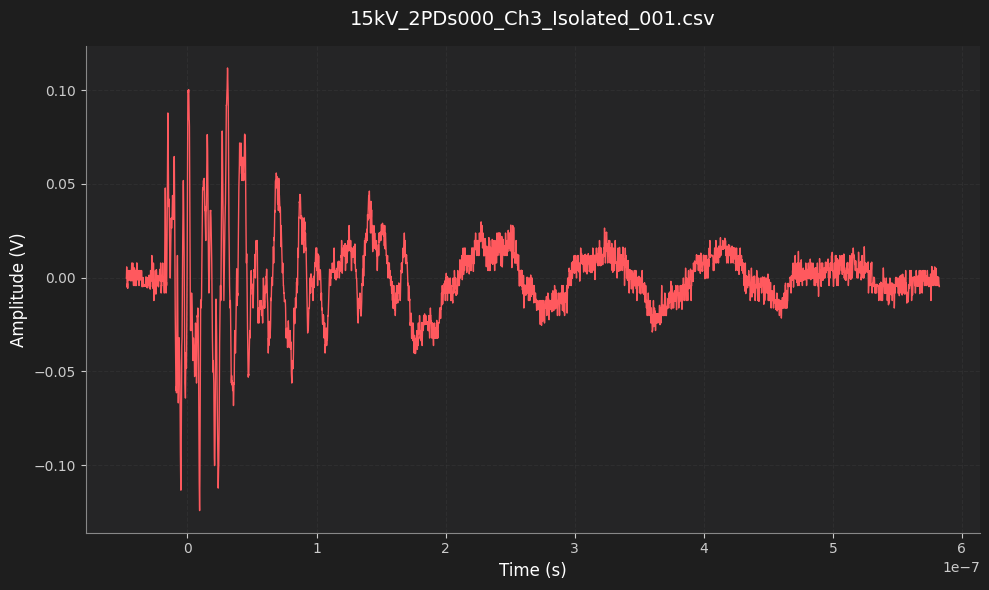

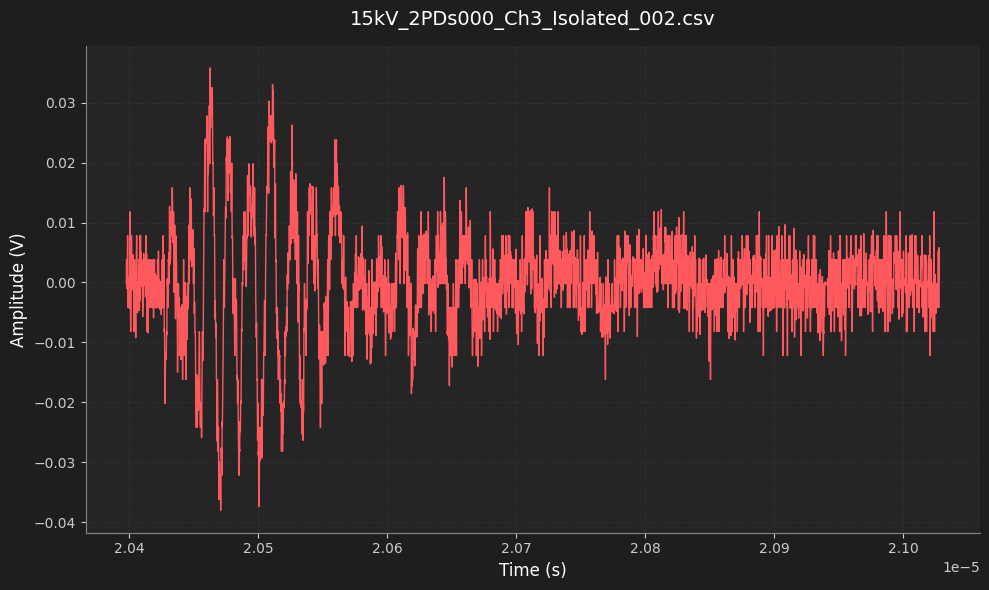

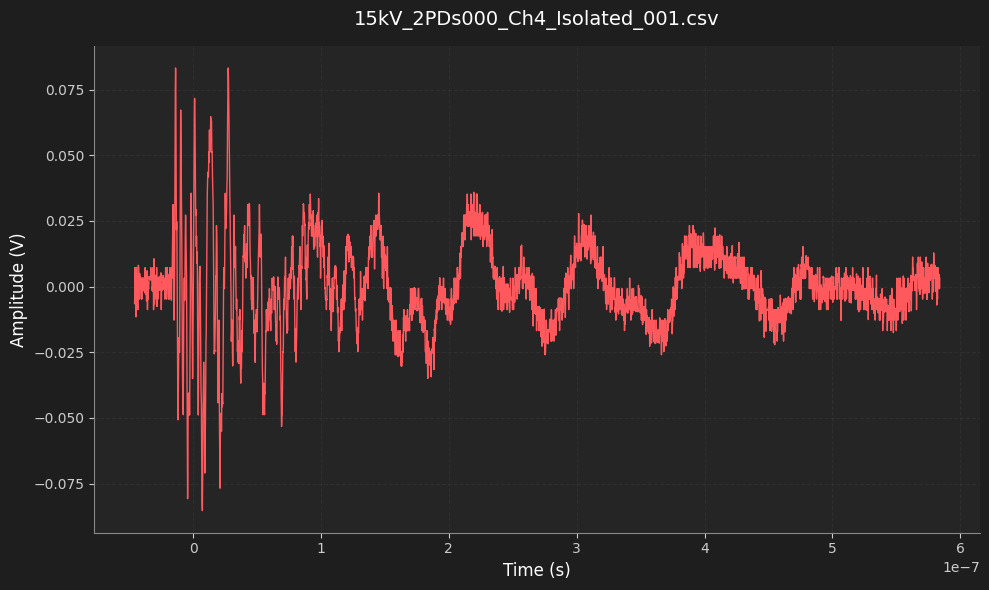

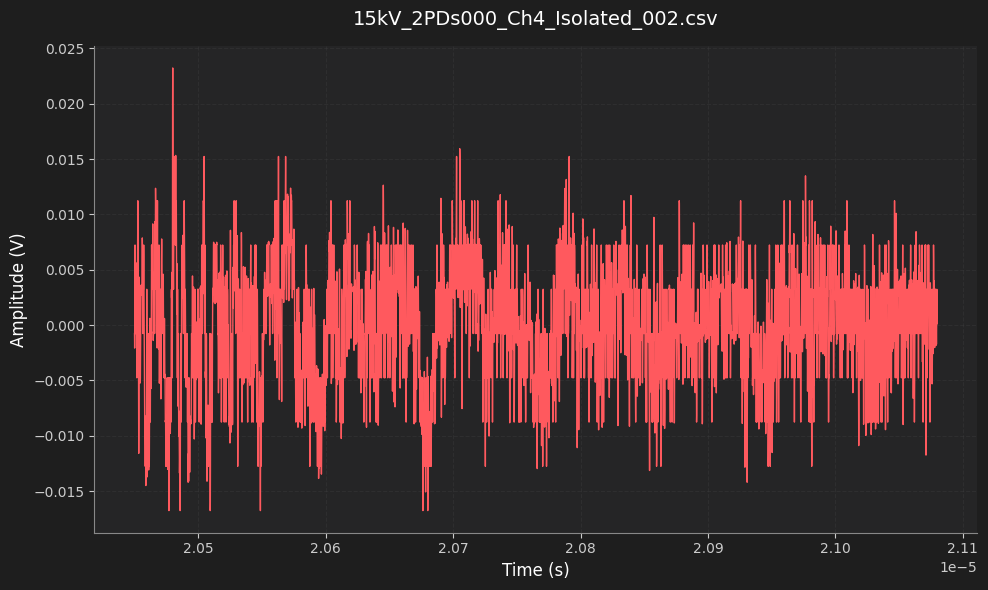

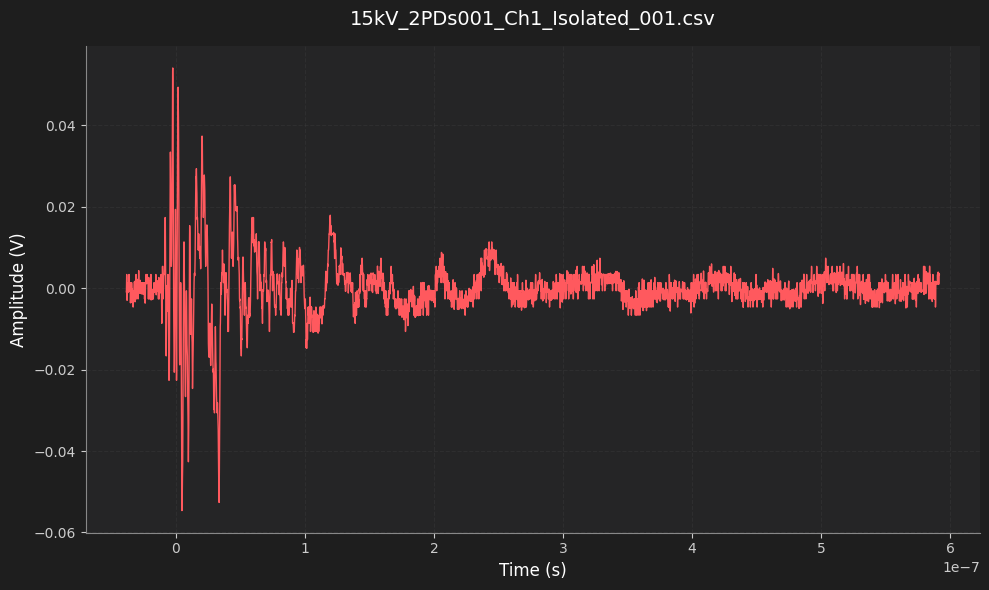

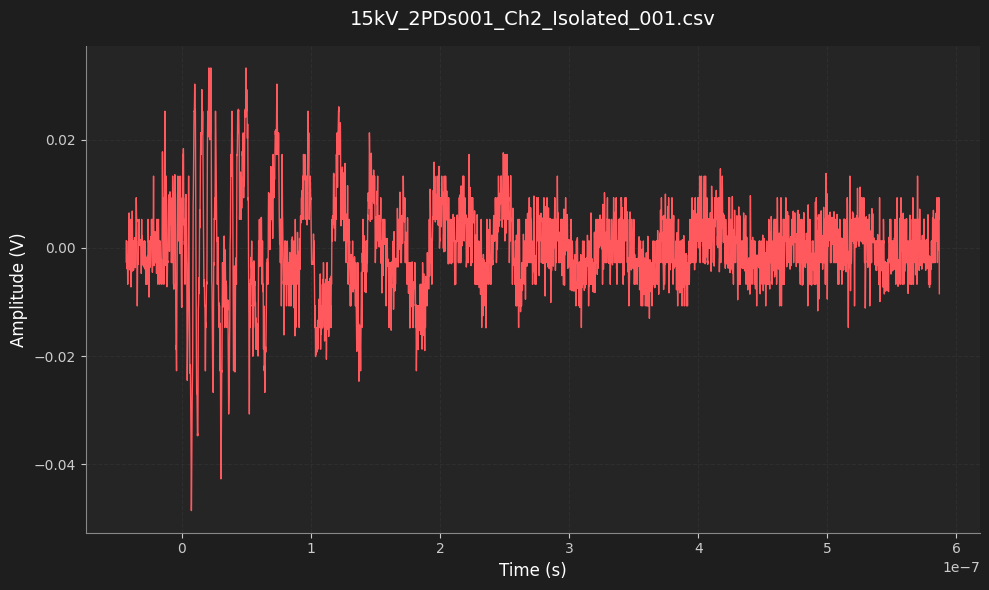

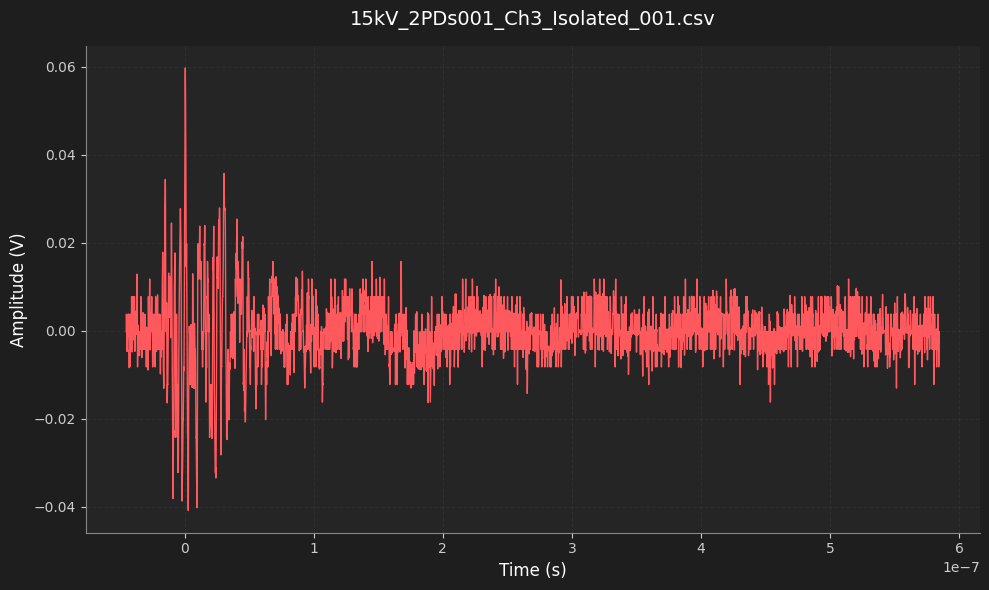

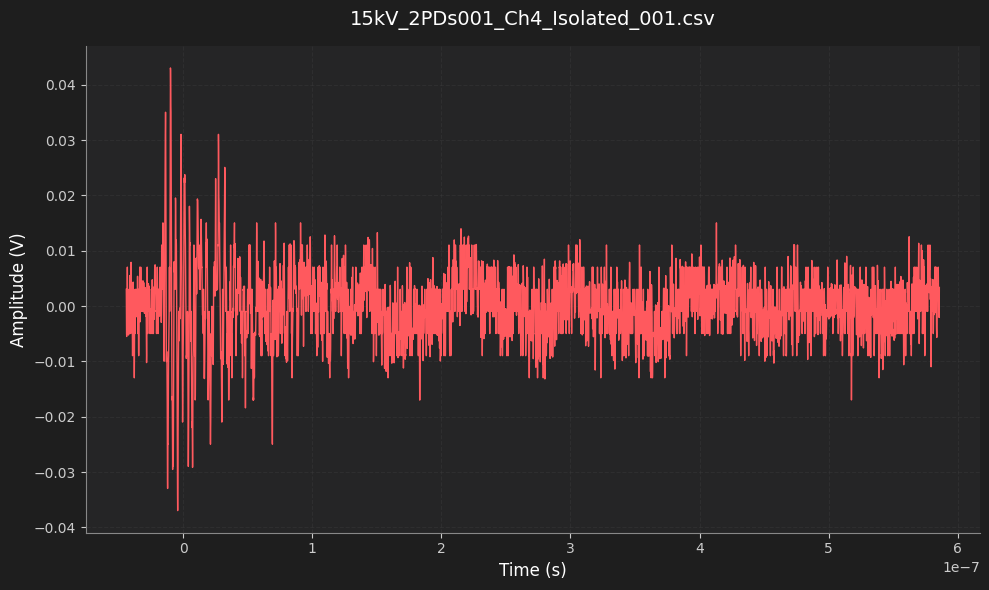

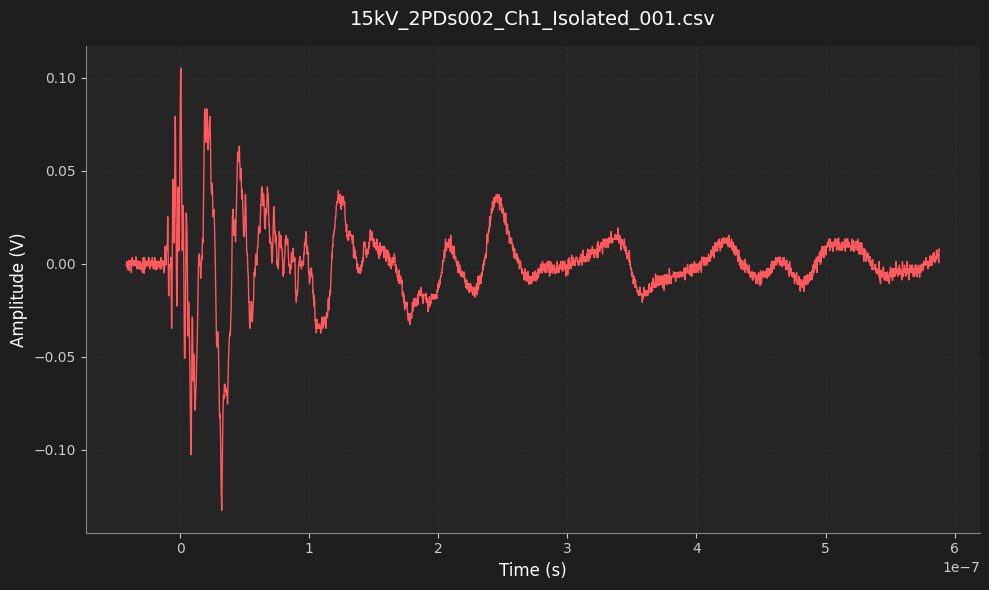

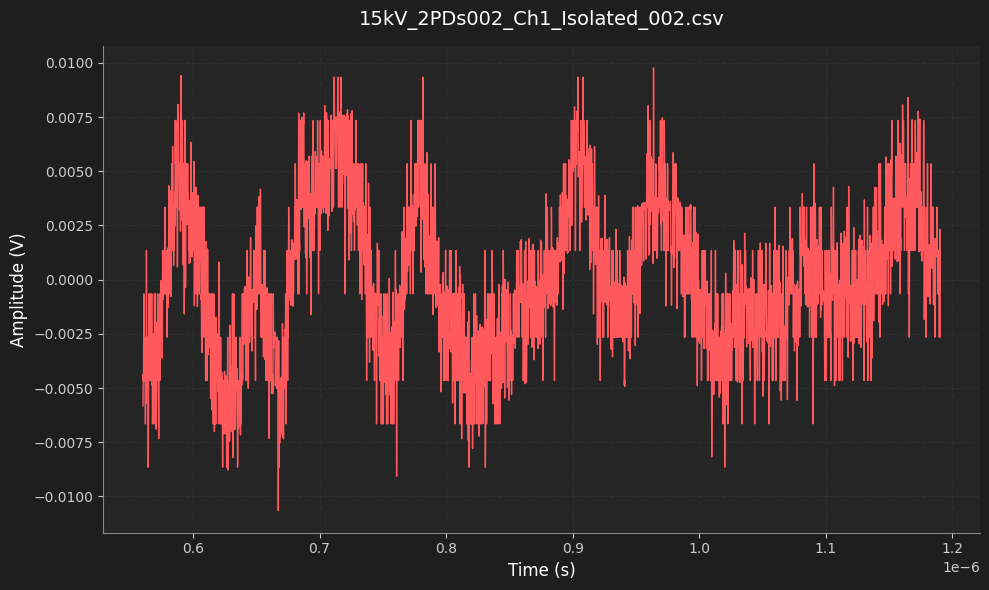

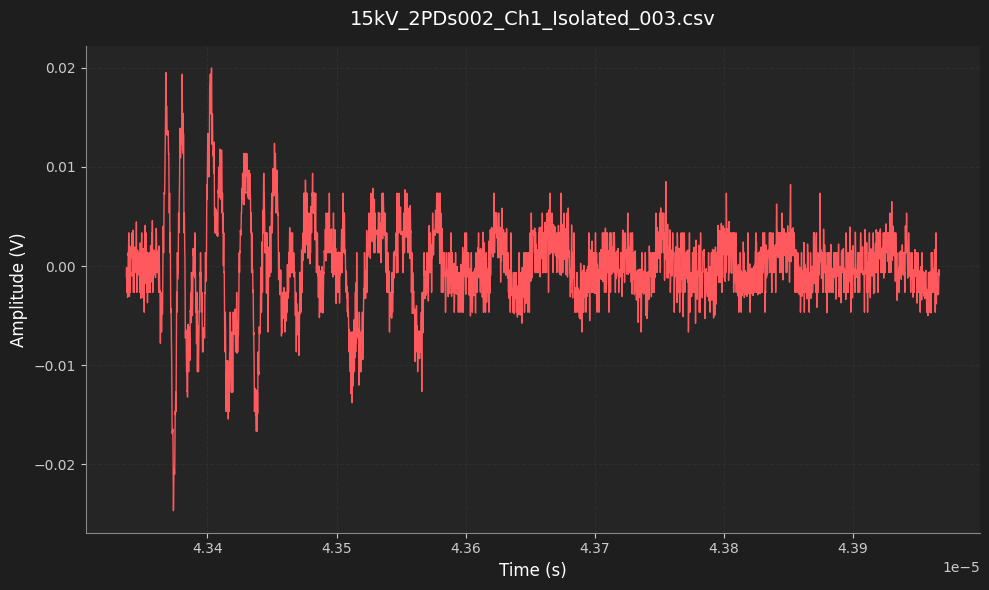

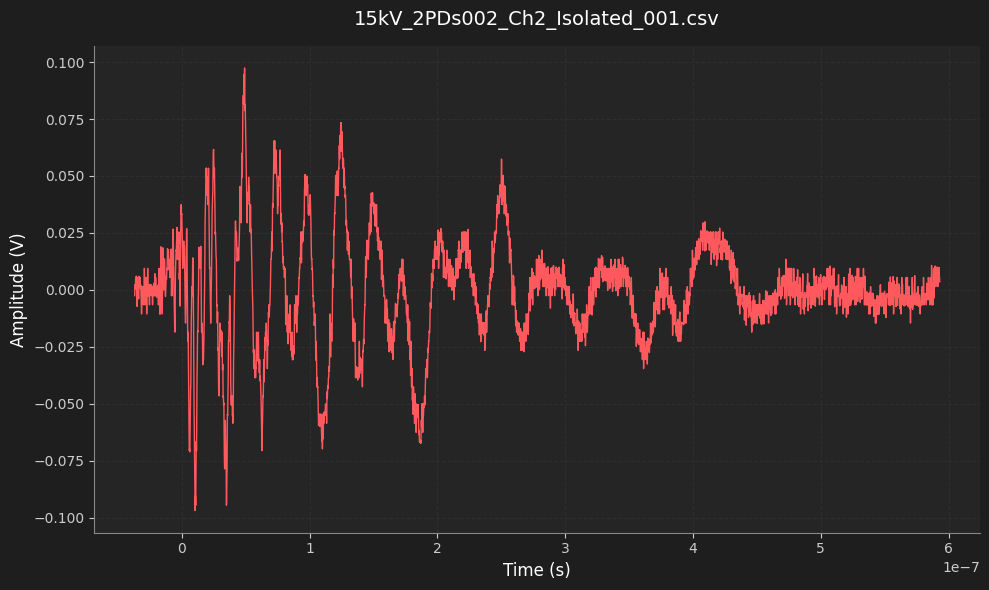

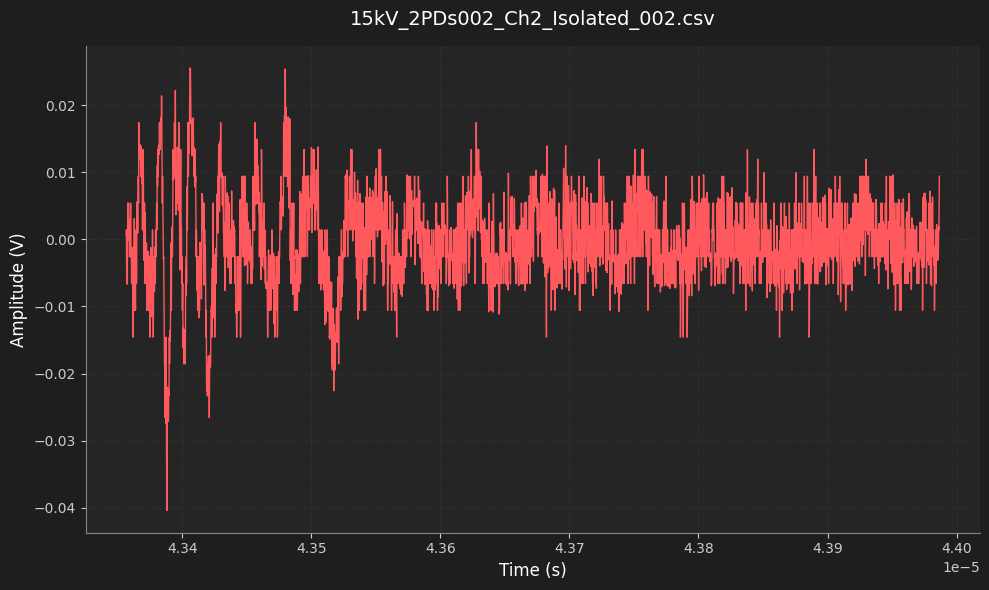

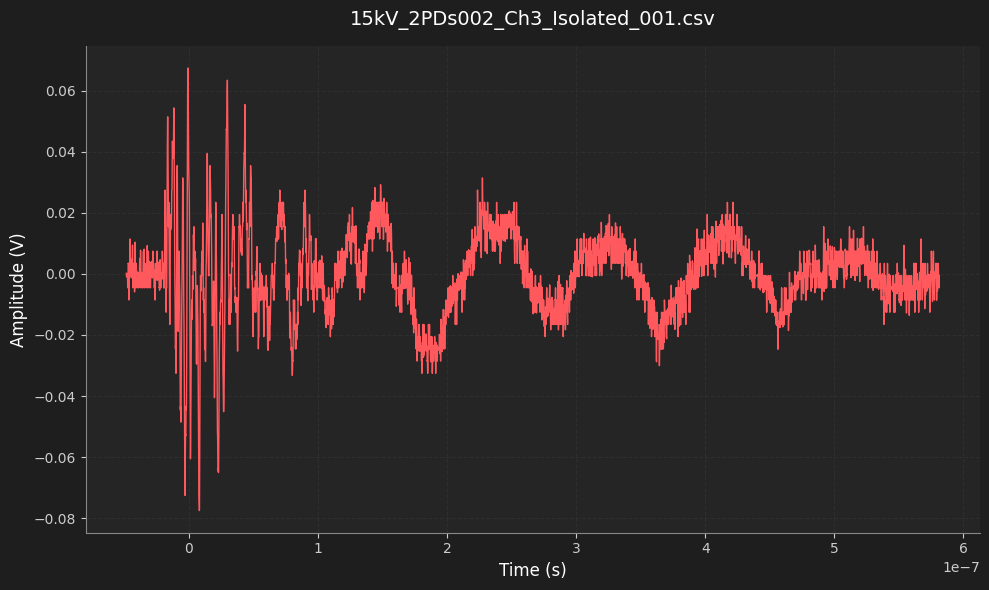

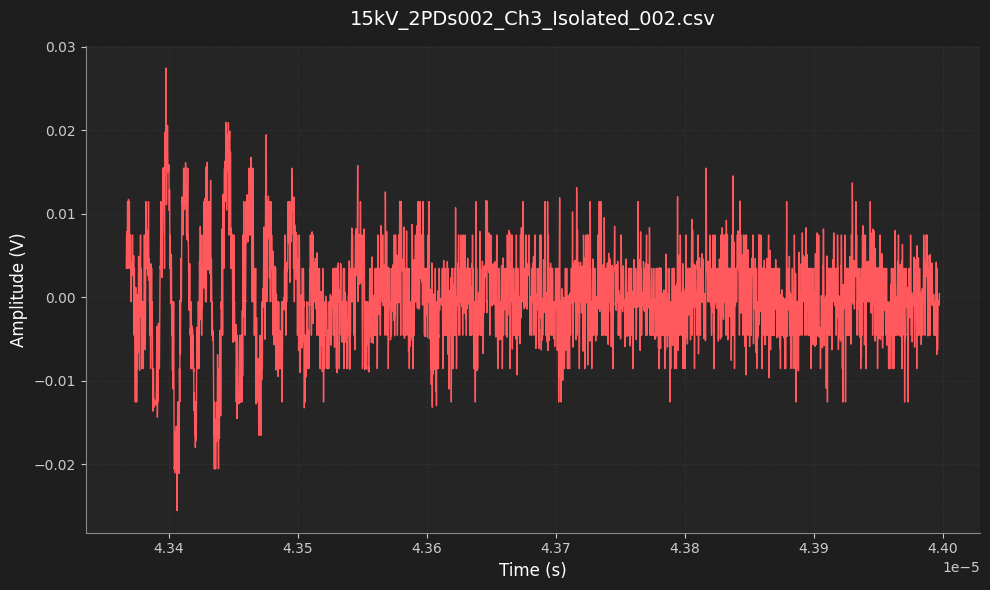

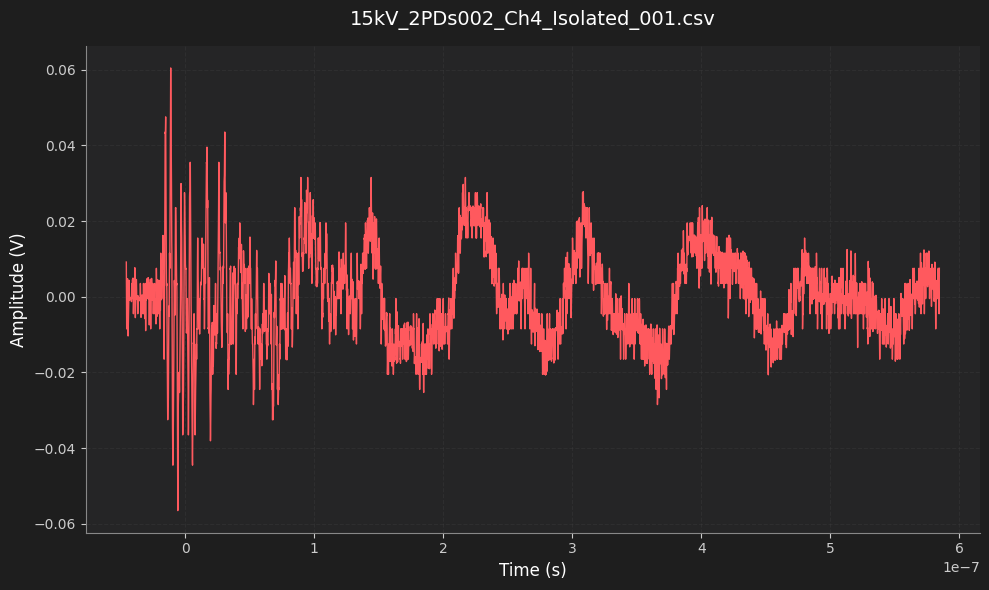

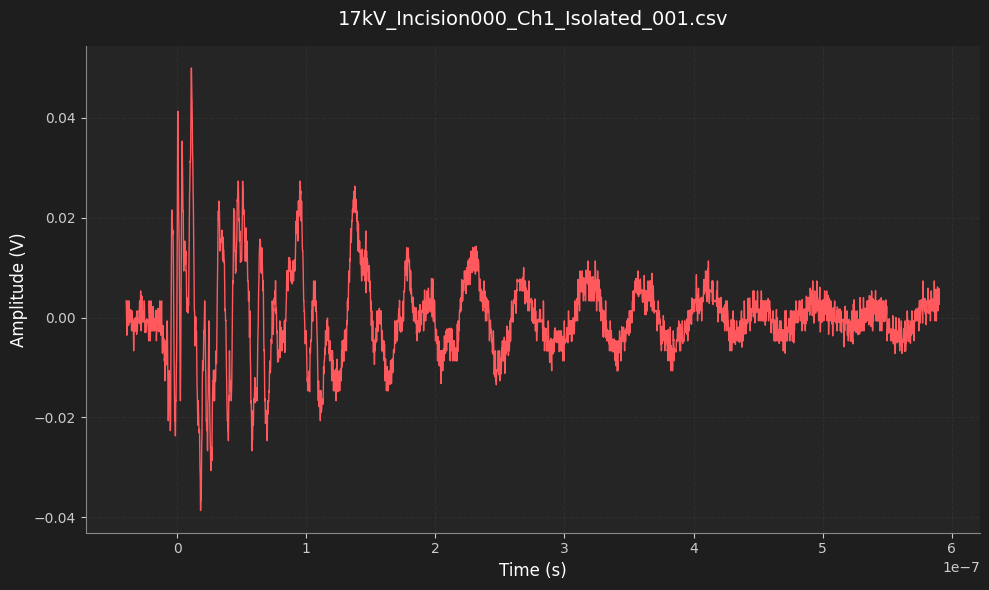

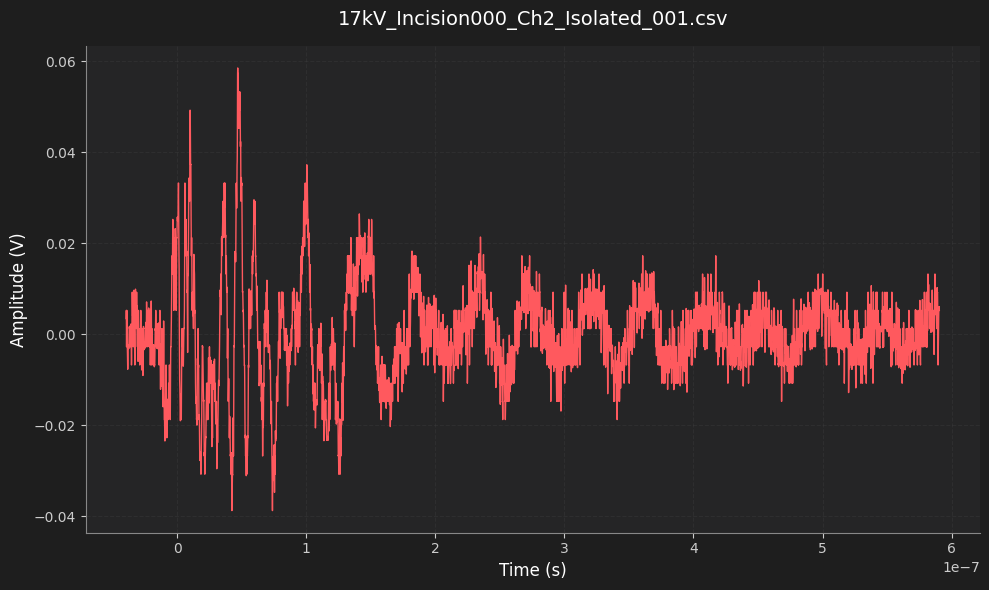

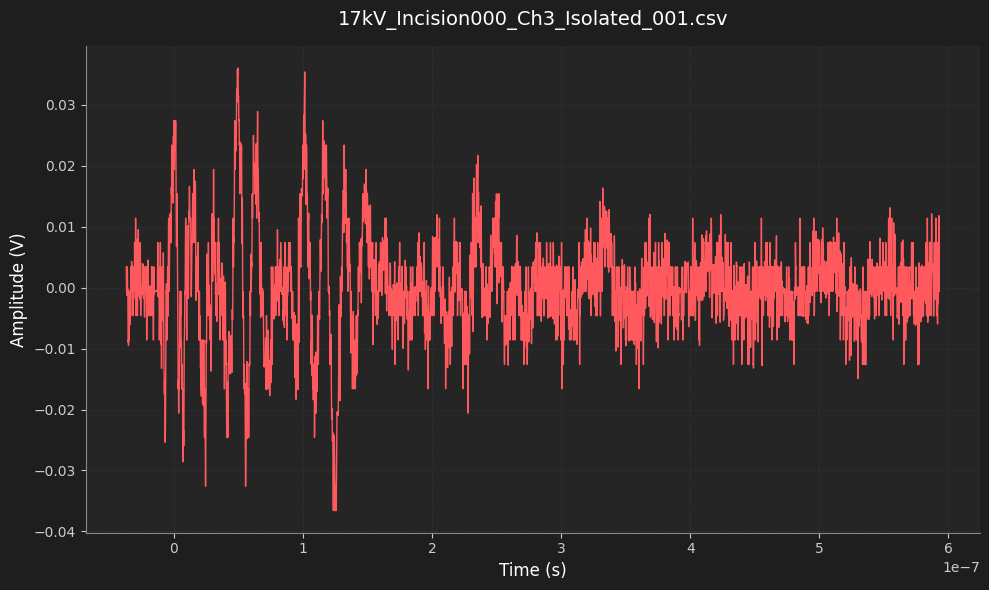

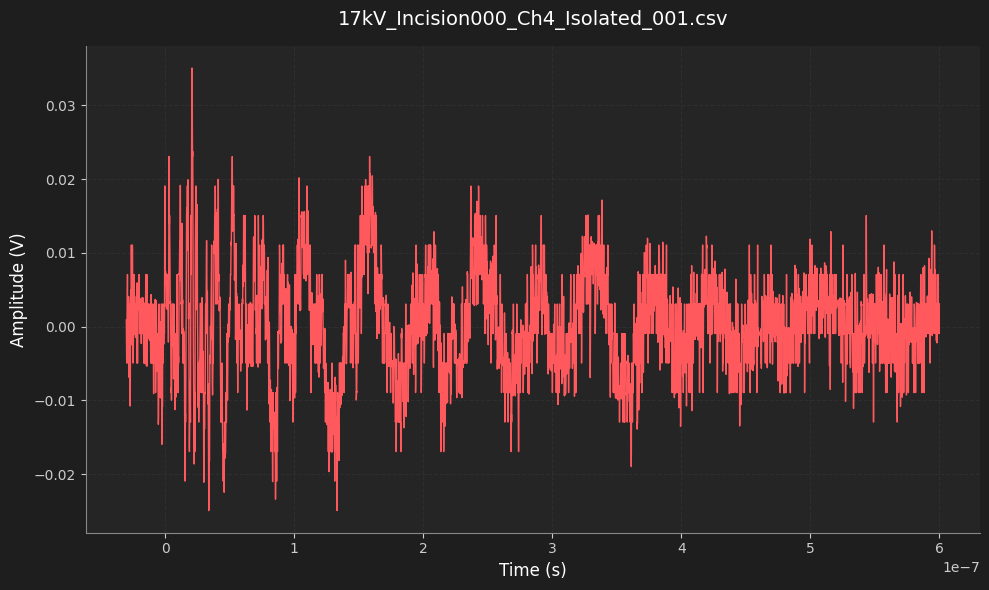

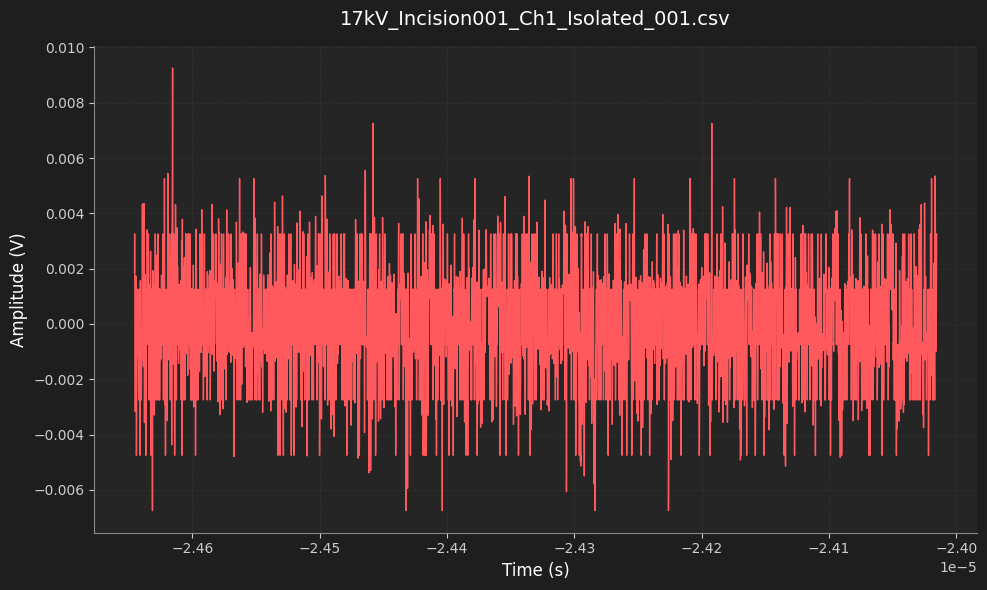

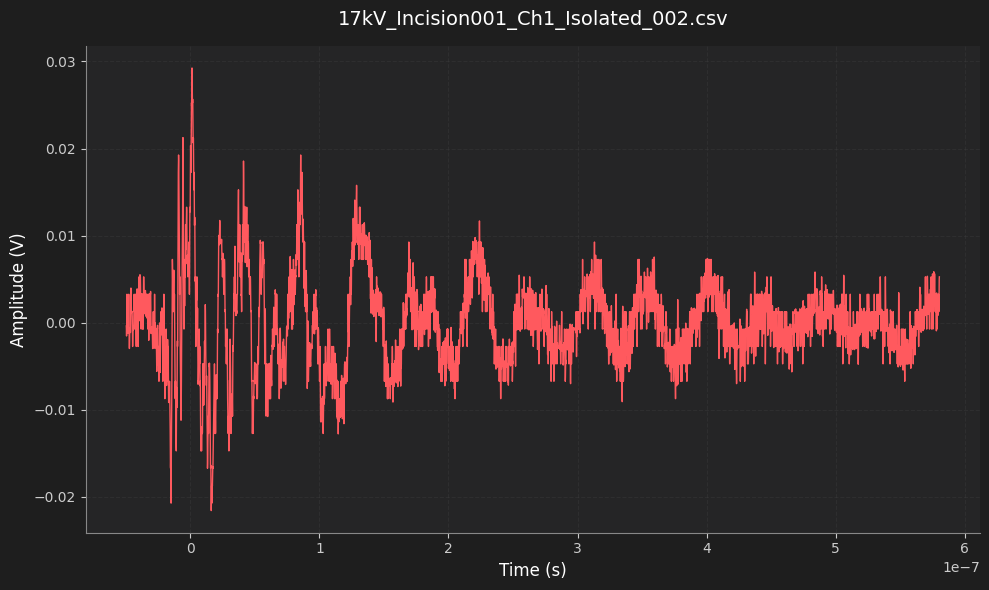

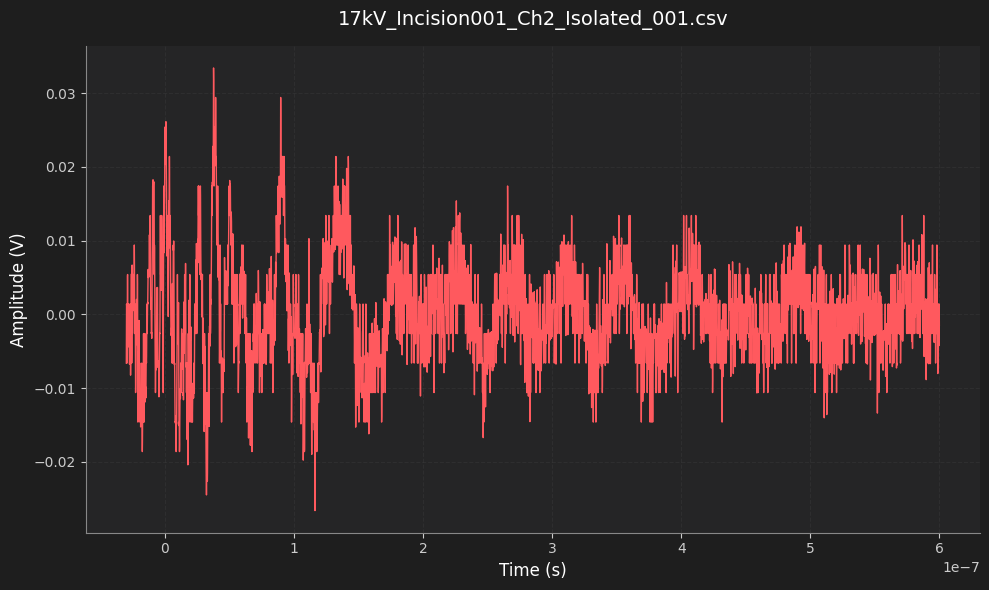

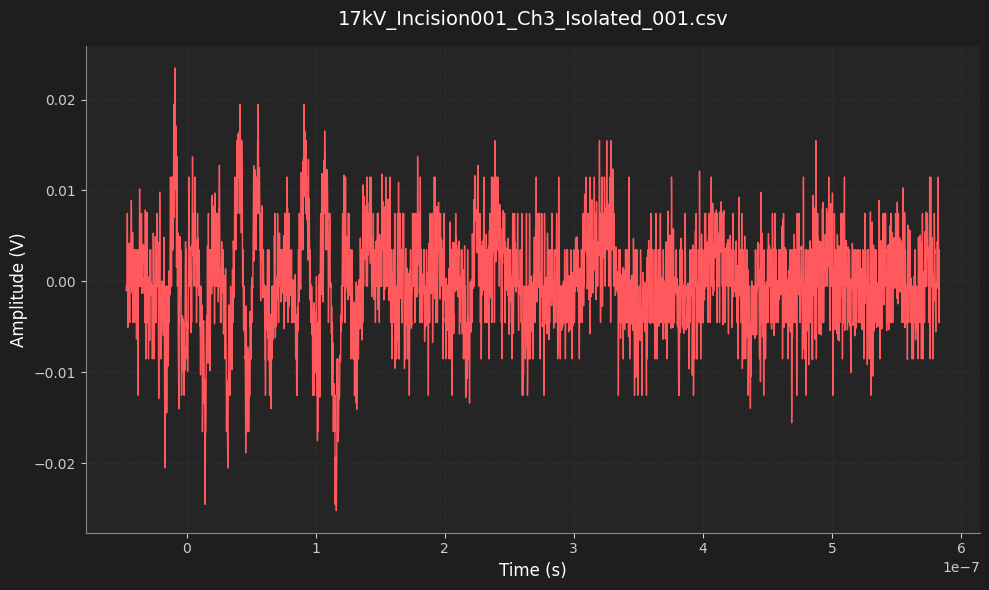

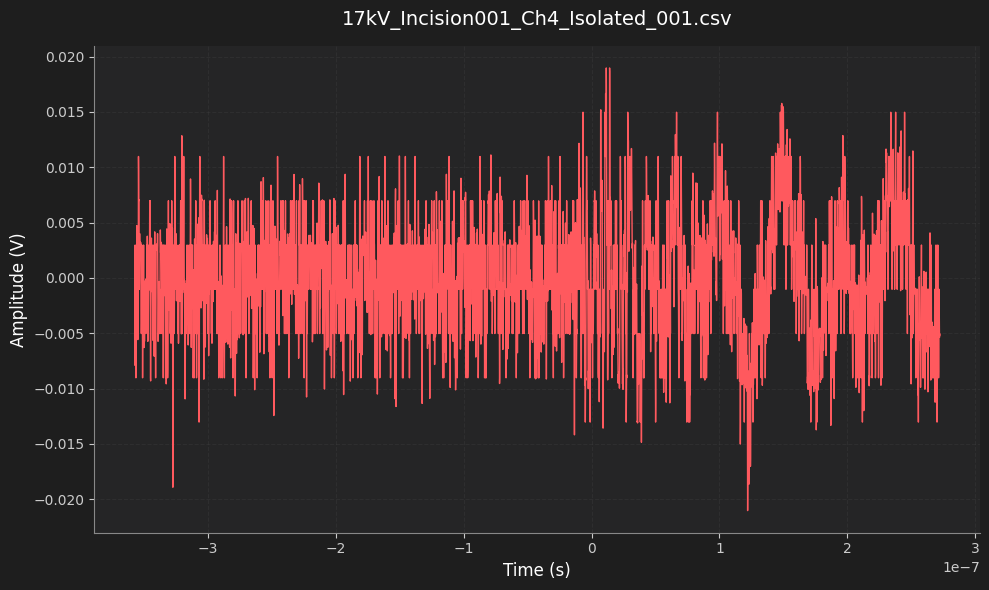

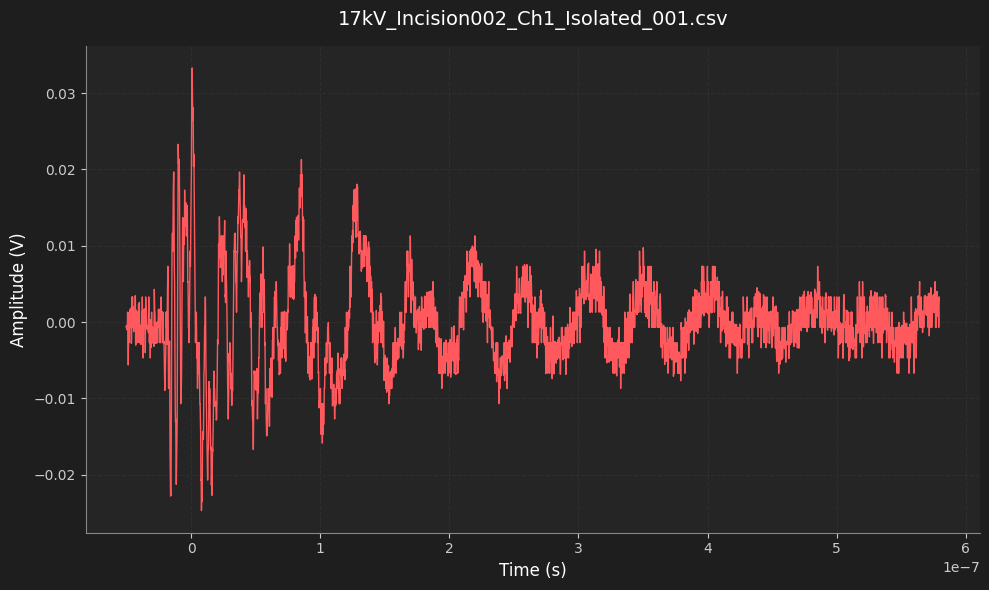

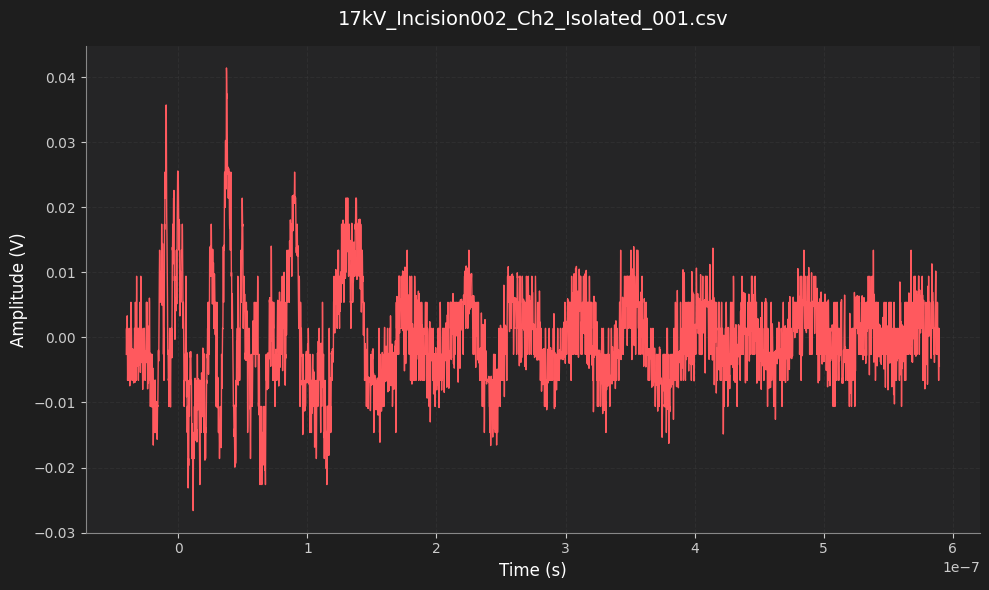

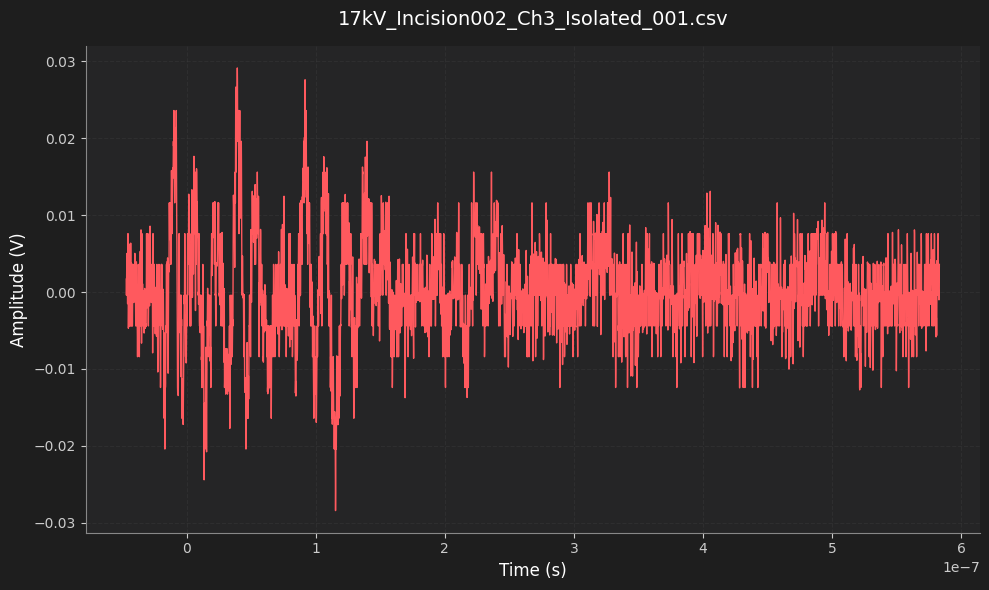

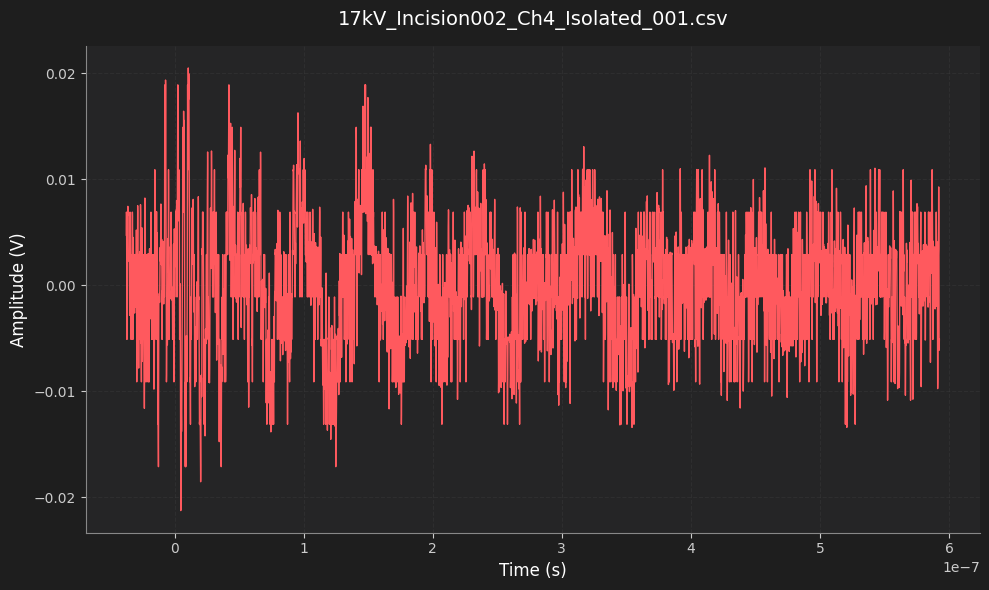

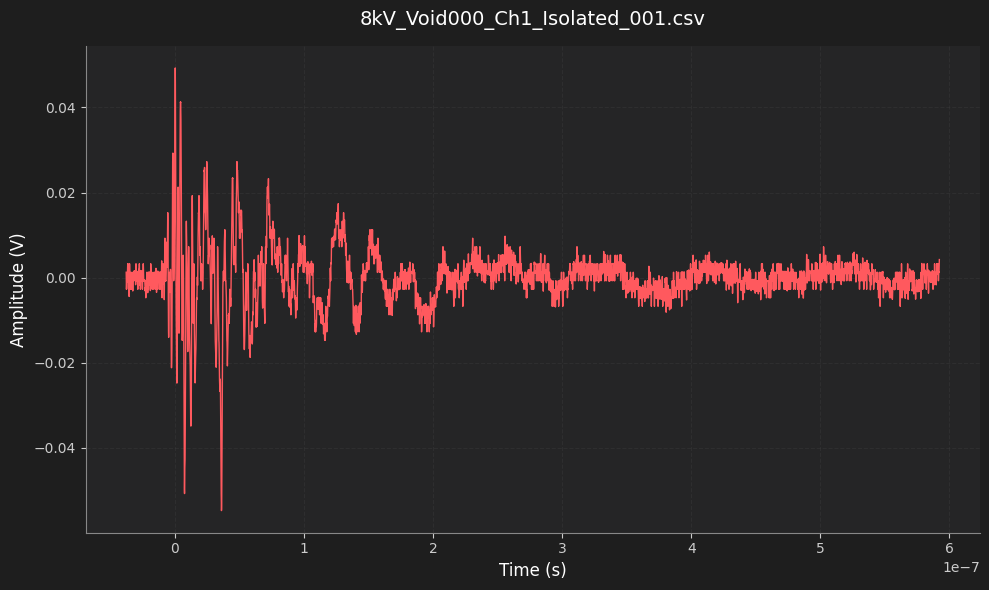

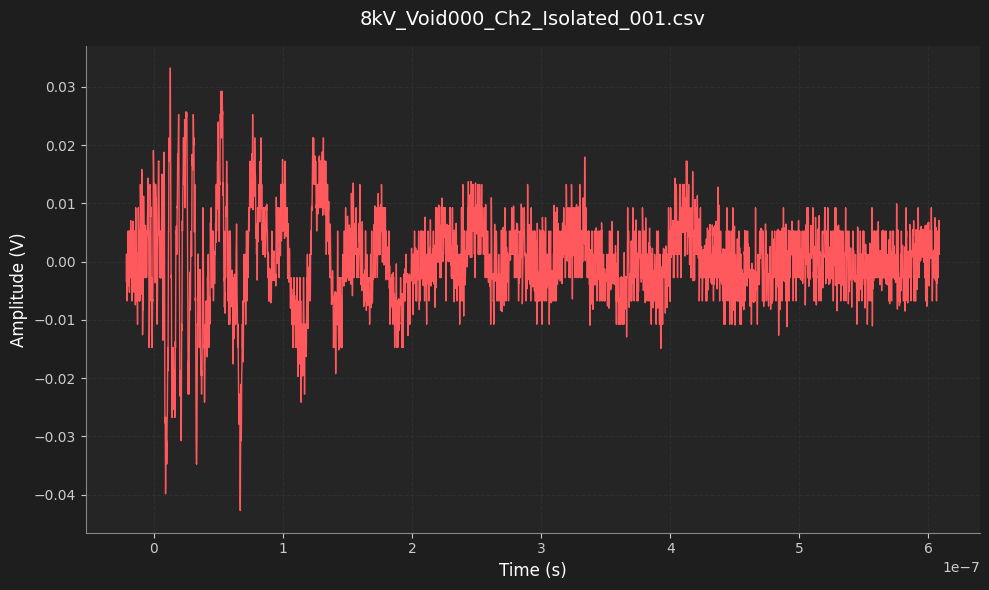

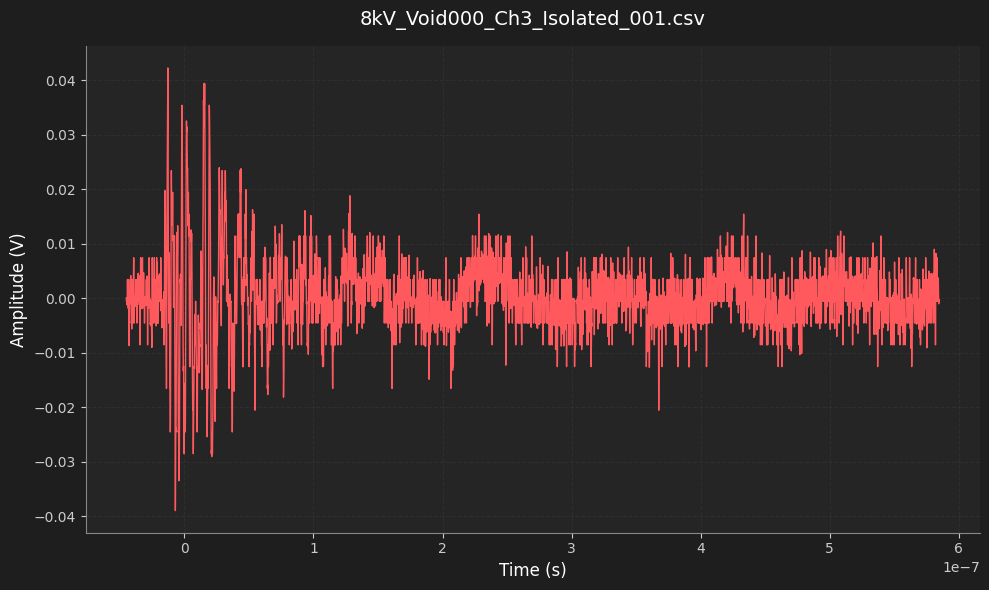

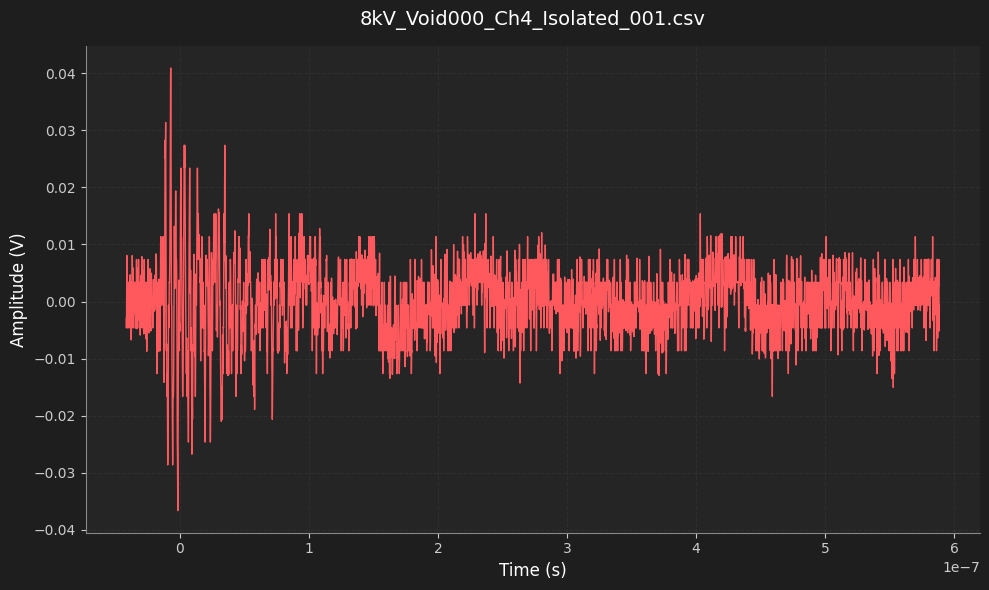

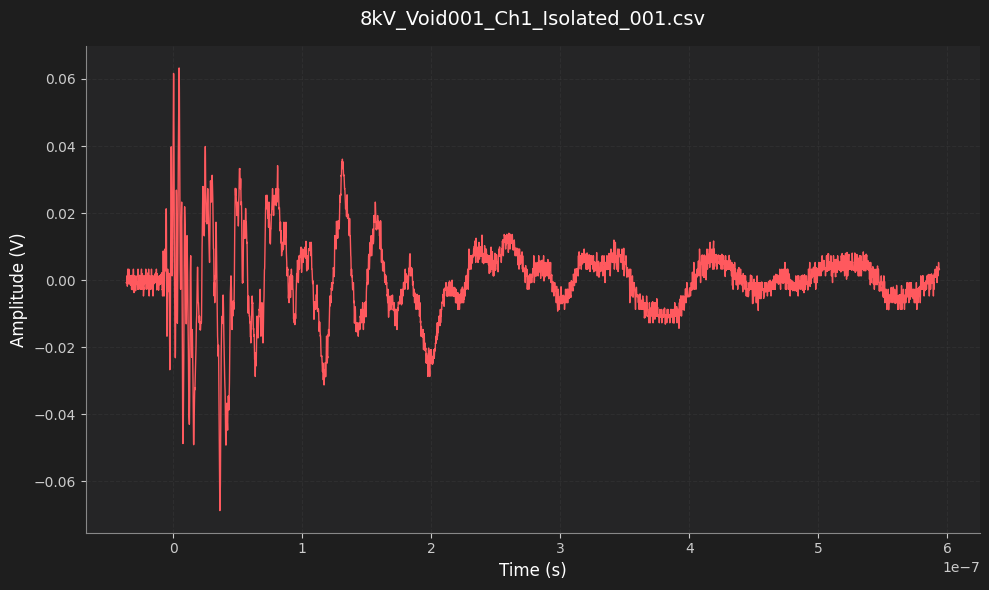

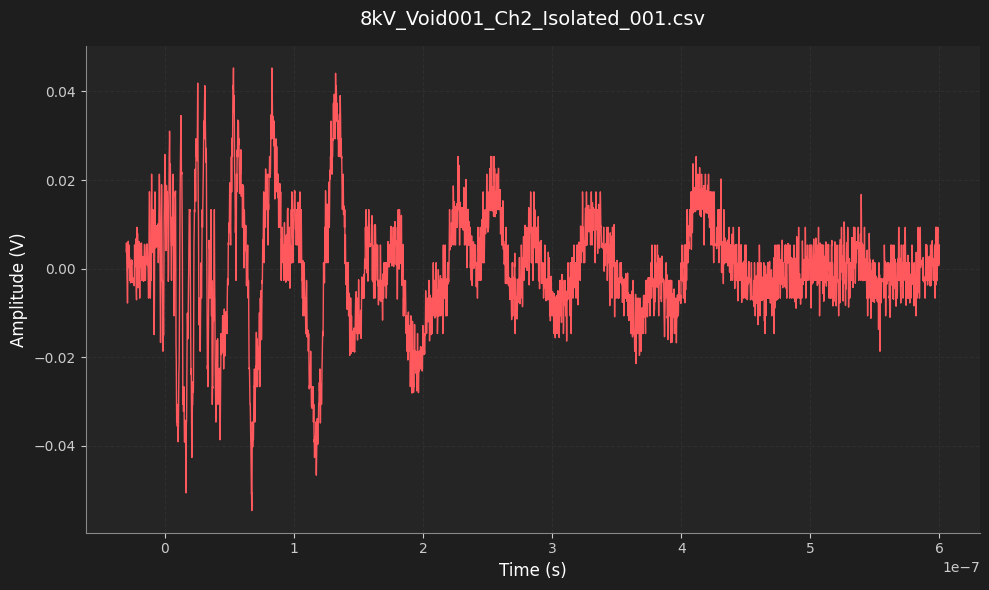

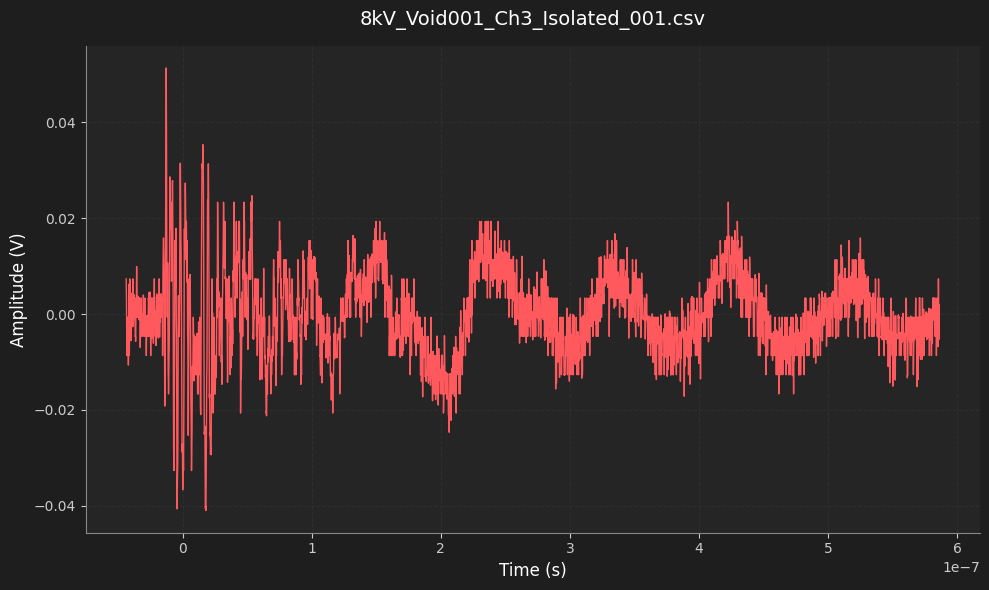

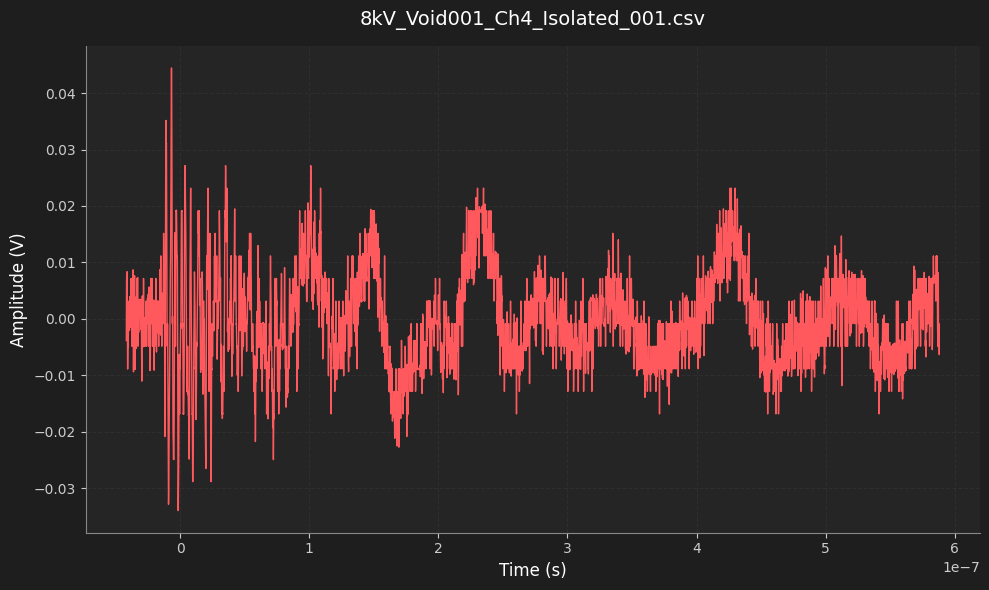

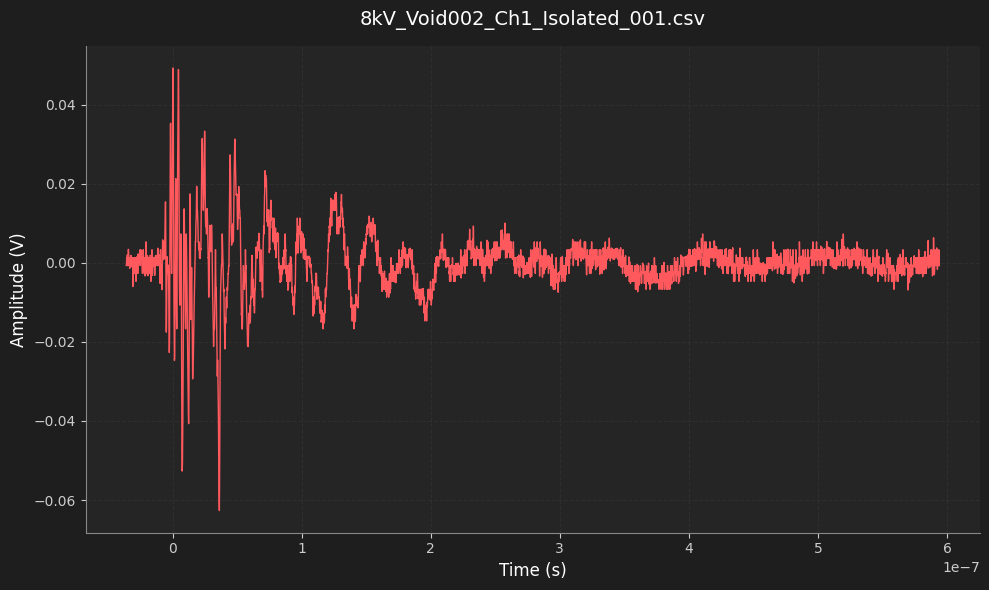

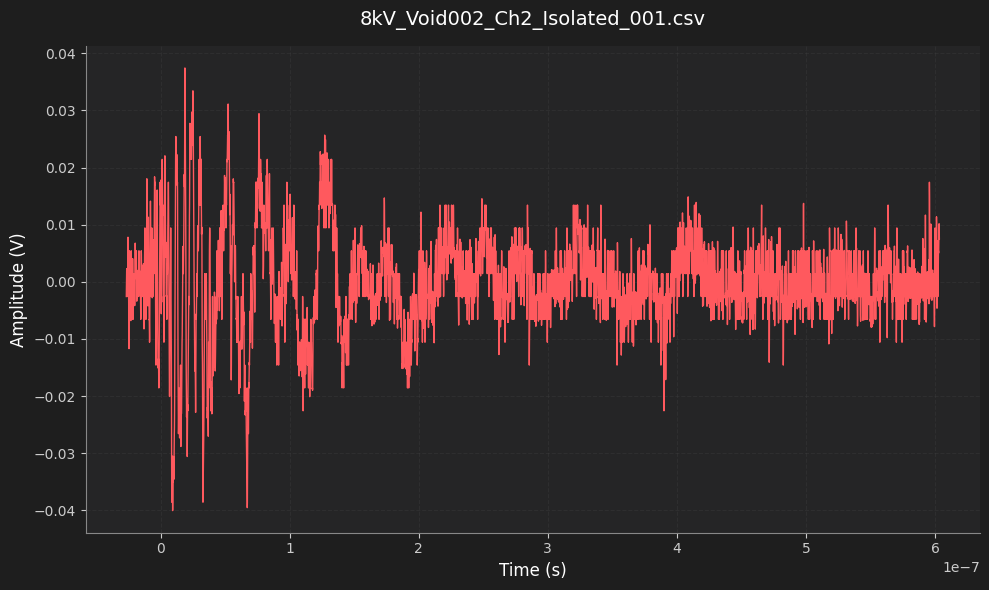

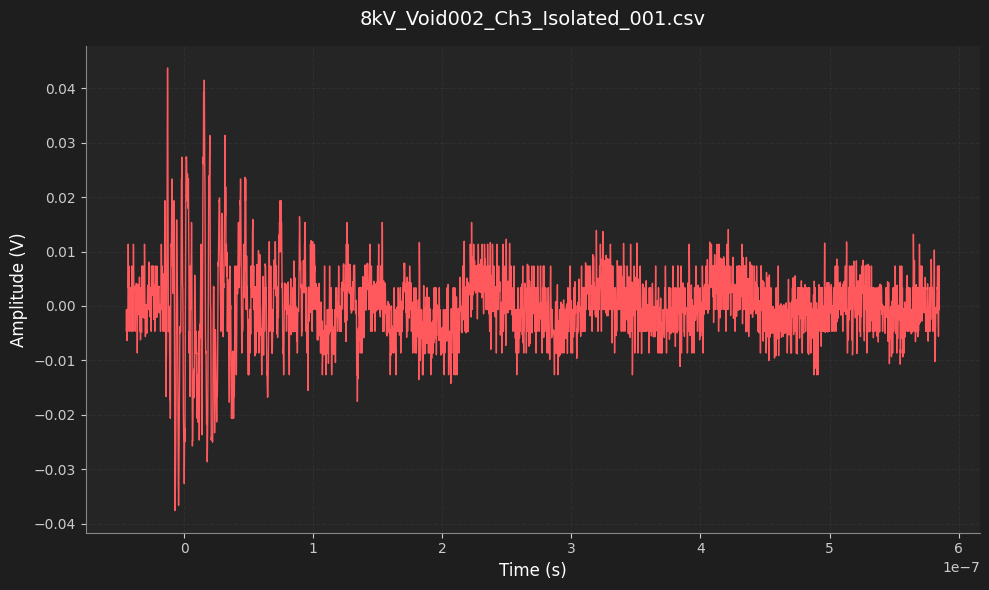

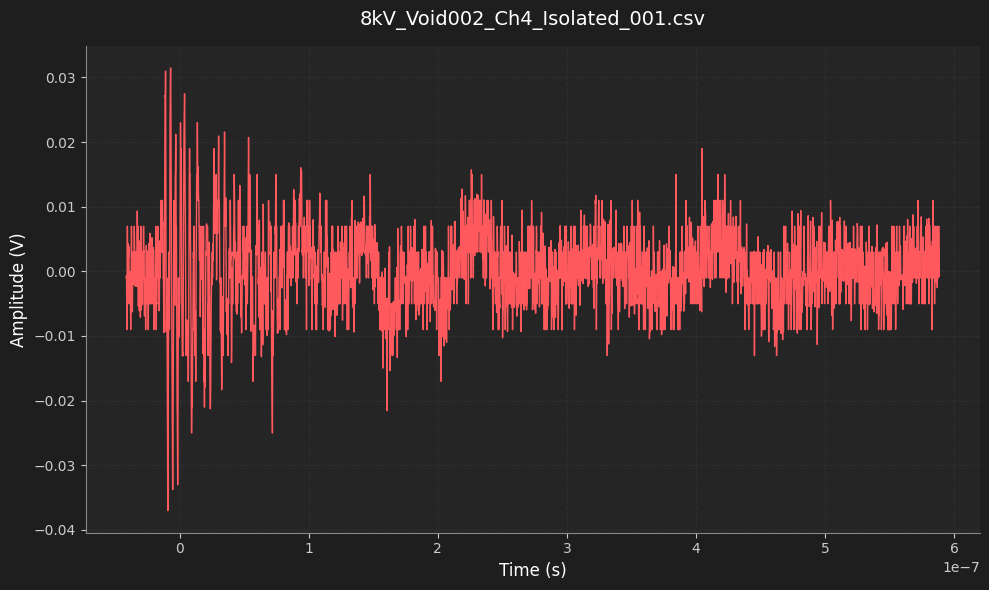

All plots generated.


In [14]:
# Set style for premium aesthetics (Dark Mode)
plt.style.use('dark_background')

INPUT_DIR = 'Isolated_Waveforms'

all_files = glob.glob(os.path.join(INPUT_DIR, '*.csv'))

if not all_files:
    print(f"No CSV files found in {INPUT_DIR}")
    sys.exit(1)

print(f"Found {len(all_files)} files to plot.")

for filepath in all_files:
    try:
        filename = os.path.basename(filepath)
        # print(f"Plotting {filename}...") # Commented out to reduce noise
        
        # Read CSV
        df = pd.read_csv(filepath, header=None, names=['Time', 'Amplitude'])
        
        # Create Figure
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#1e1e1e')
        ax.set_facecolor('#252526')
        
        # Plot
        # Adjust time if needed, here just raw time
        ax.plot(df['Time'], df['Amplitude'], color='#FF595E', linewidth=1)
        
        # Text & Labels
        ax.set_title(filename, fontsize=14, color='white', pad=15)
        ax.set_xlabel('Time (s)', fontsize=12, color='white')
        ax.set_ylabel('Amplitude (V)', fontsize=12, color='white')
        
        # Grid & Spines
        ax.grid(True, color='#444', linestyle='--', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_color('#888')
        ax.spines['left'].set_color('#888')
        ax.tick_params(axis='x', colors='#ccc')
        ax.tick_params(axis='y', colors='#ccc')
        
        plt.tight_layout()
        
        plt.show()
        
    except Exception as e:
        print(f"Error plotting {filepath}: {e}")

print("All plots generated.")


In [7]:
import numpy as np
a = np.array([1,2,3,4])
b = np.array([2,3,4,5])

import scipy.signal as signal

print(signal.correlate(a, b))

[ 5 14 26 40 29 18  8]


In [9]:
c = signal.correlation_lags(a.size, b.size, mode = 'full')
print(c)


[-3 -2 -1  0  1  2  3]


In [21]:
a = np.array([1, 2, 3, 4, 5])
b = np.array([5, 4, 3, 2, 1])
c = np.pad(b, (0,2), 'constant')[2:]
print(len(a))
print(c)

5
[3 2 1 0 0]


In [26]:
import os
import glob
INPUT_FOLDER = 'Isolated_Waveforms'

search_path = os.path.join(INPUT_FOLDER, '*')
files = sorted(glob.glob(search_path)) # Sort to ensure consistent order
(files[0]).type()

AttributeError: 'str' object has no attribute 'type'